In [1]:

# -*- coding: utf-8 -*-
"""Milestone_2.ipynb
CLIP → GPT-2 Image Captioning
Prefix Conditioning + Fine-tuning + Decoding Strategies
"""

# ============================================================
# STEP 0: Mount Google Drive & Setup Paths
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# ── Same project root as Milestone 1 ─────────────────────────
PROJECT_DIR = Path("/content/drive/MyDrive/NeuralNetworks_Project2")
DATA_DIR    = PROJECT_DIR / "coco_subset"
IMG_DIR     = DATA_DIR   / "images"
M2_DIR      = PROJECT_DIR / "milestone2"      # all M2 outputs go here
M2_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 50)
print("   Google Drive Mounted ✅")
print("=" * 50)
print(f"\n📁 Project dir   : {PROJECT_DIR}")
print(f"📁 Data dir      : {DATA_DIR}")
print(f"📁 M2 output dir : {M2_DIR}")
print("=" * 50)

Mounted at /content/drive
   Google Drive Mounted ✅

📁 Project dir   : /content/drive/MyDrive/NeuralNetworks_Project2
📁 Data dir      : /content/drive/MyDrive/NeuralNetworks_Project2/coco_subset
📁 M2 output dir : /content/drive/MyDrive/NeuralNetworks_Project2/milestone2


In [2]:
# STEP 1: Install Dependencies & Import Libraries
# ============================================================

!pip install -q transformers
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

import os, json, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import clip

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 50)
print("   STEP 1: Environment Verification")
print("=" * 50)
print(f"✅ PyTorch      : {torch.__version__}")
print(f"✅ Device       : {DEVICE.upper()}")
if DEVICE == "cpu":
    print("   ⚠️  No GPU! Go to: Runtime > Change runtime type > T4 GPU")
print(f"✅ CLIP         : imported")
print(f"✅ Transformers : imported")
print("=" * 50)
print("🎉 Step 1 complete! Proceed to Step 2.")
print("=" * 50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   STEP 1: Environment Verification
✅ PyTorch      : 2.10.0+cu128
✅ Device       : CUDA
✅ CLIP         : imported
✅ Transformers : imported
🎉 Step 1 complete! Proceed to Step 2.


In [3]:
#STEP 2: Load Milestone 1 Outputs
# Load embeddings, metadata, and tokenized captions from M1
# ============================================================

print("=" * 50)
print("   STEP 2: Load Milestone 1 Outputs")
print("=" * 50)

# ── Paths (from Milestone 1) ──────────────────────────────────
EMB_NPY   = DATA_DIR / "image_embeddings.npy"      # CLIP embeddings (N, 512)
META_JSON = DATA_DIR / "embeddings_meta.json"       # image_id, file_name, caption
TOK_PT    = DATA_DIR / "tokenized_captions.pt"      # input_ids, attention_mask

# ── Load ──────────────────────────────────────────────────────
print("\n📦 Loading Milestone 1 data...")

embeddings = np.load(EMB_NPY)                       # (N, 512) float32
with open(META_JSON, "r") as f:
    metadata = json.load(f)

tok_data       = torch.load(TOK_PT)
input_ids      = tok_data["input_ids"]              # (N, 32) int64
attention_mask = tok_data["attention_mask"]         # (N, 32) int64

print(f"\n📊 Loaded Data Summary:")
print(f"   Embeddings shape  : {embeddings.shape}")         # (N, 512)
print(f"   Metadata entries  : {len(metadata):,}")
print(f"   input_ids shape   : {input_ids.shape}")          # (N, 32)
print(f"   attention_mask    : {attention_mask.shape}")

# ── Sanity check: lengths must match ─────────────────────────
assert len(metadata) == embeddings.shape[0] == input_ids.shape[0], \
    "❌ Mismatch between embeddings, metadata, and tokens!"
print(f"\n✅ All lengths match: {len(metadata):,} entries")

# ── Quick preview ─────────────────────────────────────────────
print("\n🔍 Sample entry:")
print(f"   File    : {metadata[0]['file_name']}")
print(f"   Caption : {metadata[0]['caption']}")
print(f"   Emb[0]  : {embeddings[0][:5]} ...  (shape={embeddings[0].shape})")

print("\n" + "=" * 50)
print("🎉 Step 2 complete! Proceed to Step 3.")
print("=" * 50)

   STEP 2: Load Milestone 1 Outputs

📦 Loading Milestone 1 data...

📊 Loaded Data Summary:
   Embeddings shape  : (2500, 512)
   Metadata entries  : 2,500
   input_ids shape   : torch.Size([2500, 32])
   attention_mask    : torch.Size([2500, 32])

✅ All lengths match: 2,500 entries

🔍 Sample entry:
   File    : r_000000068130.jpg
   Caption : a group of people crossing a city street
   Emb[0]  : [-0.002705  -0.026      0.01242    0.01216   -0.0006375] ...  (shape=(512,))

🎉 Step 2 complete! Proceed to Step 3.


In [10]:
#STEP 3 (FIXED): Build the CLIP → GPT-2 Model
# Changes:
#   - Projection is now a 2-layer MLP (not a single Linear)
#   - GPT-2 weights are FROZEN — only MLP trains
#   - Use ALL 5 COCO captions per image (not just 1)
# ============================================================

print("=" * 50)
print("   STEP 3 (FIXED): Build CLIP → GPT-2 Model")
print("=" * 50)

import os, json, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────
PROJECT_DIR = Path("/content/drive/MyDrive/NeuralNetworks_Project2")
DATA_DIR    = PROJECT_DIR / "coco_subset"
IMG_DIR     = DATA_DIR / "images"
ANNO_DIR    = DATA_DIR / "annotations"
M2_DIR      = PROJECT_DIR / "milestone2"
M2_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Hyperparameters ───────────────────────────────────────────
CLIP_EMB_DIM = 512
PREFIX_LEN   = 10
GPT2_MODEL   = "gpt2"

# ── Load GPT-2 ────────────────────────────────────────────────
print("\n📦 Loading GPT-2 model & tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

gpt2 = GPT2LMHeadModel.from_pretrained(GPT2_MODEL)
GPT2_HIDDEN = gpt2.config.n_embd    # 768

# ── FREEZE all GPT-2 weights ──────────────────────────────────
for param in gpt2.parameters():
    param.requires_grad = False
print("✅ GPT-2 weights FROZEN — only projection MLP will train.")

# ── ClipCaptionModel (Fixed) ──────────────────────────────────
class ClipCaptionModel(nn.Module):
    """
    Improved prefix-conditioning model.
    - projection: 2-layer MLP with ReLU + Dropout (512 → hidden → prefix_len*768)
    - gpt2: fully frozen, used as a fixed language prior
    """
    def __init__(self, clip_dim, prefix_len, gpt2_model, hidden_dim=1024, dropout=0.1):
        super().__init__()
        self.prefix_len = prefix_len
        self.gpt2       = gpt2_model
        gpt2_hidden     = gpt2_model.config.n_embd

        # 2-layer MLP projection
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, prefix_len * gpt2_hidden)
        )

    def forward(self, clip_emb, caption_ids, attention_mask=None):
        B = clip_emb.size(0)

        # Project CLIP embedding → prefix tokens
        prefix = self.projection(clip_emb)                      # (B, prefix_len*hidden)
        prefix = prefix.view(B, self.prefix_len, -1)            # (B, prefix_len, hidden)

        # GPT-2 token embeddings for caption
        caption_emb = self.gpt2.transformer.wte(caption_ids)   # (B, seq, hidden)

        # Concatenate prefix + caption
        inputs_embeds = torch.cat([prefix, caption_emb], dim=1)

        # Build full attention mask
        if attention_mask is not None:
            prefix_mask = torch.ones(B, self.prefix_len,
                                     dtype=attention_mask.dtype,
                                     device=attention_mask.device)
            full_mask = torch.cat([prefix_mask, attention_mask], dim=1)
        else:
            full_mask = None

        outputs = self.gpt2(inputs_embeds=inputs_embeds, attention_mask=full_mask)
        return outputs.logits

# ── Instantiate ───────────────────────────────────────────────
model = ClipCaptionModel(
    clip_dim   = CLIP_EMB_DIM,
    prefix_len = PREFIX_LEN,
    gpt2_model = gpt2
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Summary:")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}  ← only MLP")
print(f"   Frozen params    : {total_params - trainable_params:,}  ← GPT-2")

# ── Quick forward pass test ───────────────────────────────────
print("\n🧪 Testing forward pass...")
dummy_emb  = torch.randn(2, CLIP_EMB_DIM).to(DEVICE)
dummy_ids  = torch.randint(0, 50257, (2, 32)).to(DEVICE)
dummy_mask = torch.ones(2, 32).to(DEVICE)
with torch.no_grad():
    logits = model(dummy_emb, dummy_ids, dummy_mask)
print(f"   Output logits: {logits.shape}  ✅")

print("\n" + "=" * 50)
print("🎉 Step 3 (Fixed) complete! Proceed to Step 4 (Fixed).")
print("=" * 50)

   STEP 3 (FIXED): Build CLIP → GPT-2 Model

📦 Loading GPT-2 model & tokenizer...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ GPT-2 weights FROZEN — only projection MLP will train.

📊 Model Summary:
   Total params     : 132,837,120
   Trainable params : 8,397,312  ← only MLP
   Frozen params    : 124,439,808  ← GPT-2

🧪 Testing forward pass...
   Output logits: torch.Size([2, 42, 50257])  ✅

🎉 Step 3 (Fixed) complete! Proceed to Step 4 (Fixed).


In [11]:
#STEP 4 (FIXED): Dataset using ALL 5 Captions per Image
# Instead of 1 caption per image → 5× more training data
# ============================================================

print("=" * 50)
print("   STEP 4 (FIXED): Dataset — All 5 Captions per Image")
print("=" * 50)

MAX_LENGTH = 32
SEED       = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Load CLIP embeddings & metadata from M1 ───────────────────
EMB_NPY   = DATA_DIR / "image_embeddings.npy"
META_JSON = DATA_DIR / "embeddings_meta.json"

embeddings_np = np.load(EMB_NPY)
with open(META_JSON, "r") as f:
    metadata = json.load(f)

# Build image_id → embedding index lookup
id_to_idx = {entry["image_id"]: i for i, entry in enumerate(metadata)}

# ── Load COCO annotations to get ALL 5 captions ──────────────
ANNO_FILE = ANNO_DIR / "captions_train2017.json"
print(f"\n📂 Loading all COCO captions from {ANNO_FILE.name}...")
with open(ANNO_FILE, "r") as f:
    coco_raw = json.load(f)

# Build image_id → [caption1, caption2, ..., caption5]
id_to_captions = {}
for ann in coco_raw["annotations"]:
    iid = ann["image_id"]
    if iid not in id_to_captions:
        id_to_captions[iid] = []
    id_to_captions[iid].append(ann["caption"].lower().strip())

# ── Build expanded dataset: 1 row per (image, caption) pair ──
import re
def clean_caption(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s.,!?'-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

all_embeddings = []
all_captions   = []

for entry in metadata:
    iid = entry["image_id"]
    if iid not in id_to_idx:
        continue
    emb_idx   = id_to_idx[iid]
    emb_vec   = embeddings_np[emb_idx]
    captions  = id_to_captions.get(iid, [entry["caption"]])

    for cap in captions:
        cleaned = clean_caption(cap)
        words   = cleaned.split()
        if len(words) < 3 or len(words) > 50:
            continue
        all_embeddings.append(emb_vec)
        all_captions.append(cleaned)

print(f"✅ Expanded dataset: {len(all_captions):,} (image, caption) pairs")
print(f"   (was {len(metadata):,} with 1 caption → now ~5× more)")

# ── Tokenize all captions ─────────────────────────────────────
print(f"\n🔄 Tokenizing {len(all_captions):,} captions...")
encoding = tokenizer(
    all_captions,
    padding        = "max_length",
    truncation     = True,
    max_length     = MAX_LENGTH,
    return_tensors = "pt"
)
all_input_ids   = encoding["input_ids"]        # (N, 32)
all_attn_mask   = encoding["attention_mask"]   # (N, 32)
all_emb_tensor  = torch.tensor(np.array(all_embeddings), dtype=torch.float32)

print(f"   input_ids shape  : {all_input_ids.shape}")
print(f"   embeddings shape : {all_emb_tensor.shape}")

# ── Train / Val split ─────────────────────────────────────────
N          = len(all_captions)
val_size   = int(0.1 * N)
train_size = N - val_size
indices    = list(range(N))
random.shuffle(indices)
train_idx, val_idx = indices[:train_size], indices[train_size:]

class CocoCaptionDataset(Dataset):
    def __init__(self, emb, ids, mask):
        self.emb  = emb
        self.ids  = ids
        self.mask = mask
    def __len__(self):
        return len(self.emb)
    def __getitem__(self, i):
        return self.emb[i], self.ids[i], self.mask[i]

BATCH_SIZE   = 32
train_dataset = CocoCaptionDataset(all_emb_tensor[train_idx], all_input_ids[train_idx], all_attn_mask[train_idx])
val_dataset   = CocoCaptionDataset(all_emb_tensor[val_idx],   all_input_ids[val_idx],   all_attn_mask[val_idx])
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n📊 Dataset Split:")
print(f"   Total  : {N:,}")
print(f"   Train  : {train_size:,}  ({len(train_loader)} batches)")
print(f"   Val    : {val_size:,}   ({len(val_loader)} batches)")

print("\n" + "=" * 50)
print("🎉 Step 4 (Fixed) complete! Proceed to Step 5 (Fixed).")
print("=" * 50)

   STEP 4 (FIXED): Dataset — All 5 Captions per Image

📂 Loading all COCO captions from captions_train2017.json...
✅ Expanded dataset: 12,511 (image, caption) pairs
   (was 2,500 with 1 caption → now ~5× more)

🔄 Tokenizing 12,511 captions...
   input_ids shape  : torch.Size([12511, 32])
   embeddings shape : torch.Size([12511, 512])

📊 Dataset Split:
   Total  : 12,511
   Train  : 11,260  (352 batches)
   Val    : 1,251   (40 batches)

🎉 Step 4 (Fixed) complete! Proceed to Step 5 (Fixed).


   STEP 5 (FIXED): Fine-tune Projection MLP

⚙️  Config:
   Epochs (max)     : 10
   Early stop (pat) : 3
   LR               : 0.0001
   Batch size       : 32
   Training pairs   : 11,260

🚀 Starting training...

   Epoch 1/10 | Step 50/352 | Loss: 3.7280
   Epoch 1/10 | Step 100/352 | Loss: 3.7266
   Epoch 1/10 | Step 150/352 | Loss: 3.4523
   Epoch 1/10 | Step 200/352 | Loss: 3.4512
   Epoch 1/10 | Step 250/352 | Loss: 3.6066
   Epoch 1/10 | Step 300/352 | Loss: 3.2999
   Epoch 1/10 | Step 350/352 | Loss: 3.3569

  Epoch 1/10 Summary
  Train Loss : 3.6752
  Val Loss   : 3.0687
  💾 Best model saved (val_loss=3.0687)

   Epoch 2/10 | Step 50/352 | Loss: 3.2009
   Epoch 2/10 | Step 100/352 | Loss: 3.1144
   Epoch 2/10 | Step 150/352 | Loss: 3.1716
   Epoch 2/10 | Step 200/352 | Loss: 2.9684
   Epoch 2/10 | Step 250/352 | Loss: 3.1727
   Epoch 2/10 | Step 300/352 | Loss: 2.8335
   Epoch 2/10 | Step 350/352 | Loss: 3.1973

  Epoch 2/10 Summary
  Train Loss : 3.1371
  Val Loss   : 2.9131


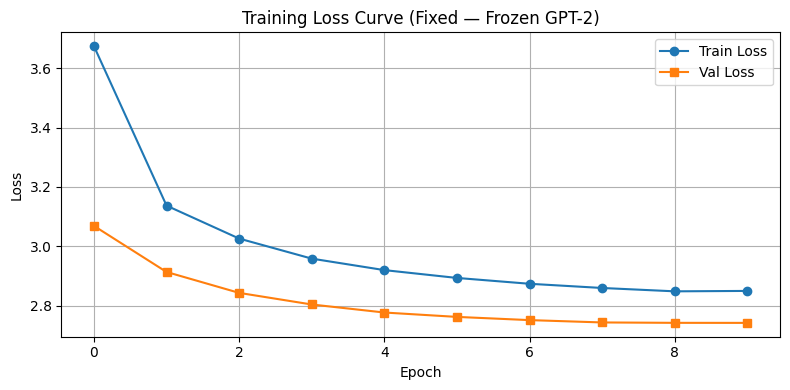


💾 Loss curve saved → /content/drive/MyDrive/NeuralNetworks_Project2/milestone2/loss_curve_fixed.png

🎉 Step 5 (Fixed) complete! Best val loss: 2.7414
   Proceed to Step 6 (no changes needed).


In [12]:
#STEP 5 (FIXED): Fine-tune — Only MLP Projection
# Changes:
#   - Only projection MLP parameters are passed to optimizer
#   - More epochs (10) with early stopping (patience=3)
#   - Lower LR (1e-4) since we're training far fewer params
# ============================================================

print("=" * 50)
print("   STEP 5 (FIXED): Fine-tune Projection MLP")
print("=" * 50)

import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

NUM_EPOCHS = 10
LR         = 1e-4
PATIENCE   = 3          # stop if val loss doesn't improve for 3 epochs
LOG_EVERY  = 50
CKPT_PATH  = M2_DIR / "best_model_fixed.pt"

ce_loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

def compute_caption_loss(logits, caption_ids, prefix_len):
    cap_logits = logits[:, prefix_len:-1, :]    # (B, seq-1, vocab)
    targets    = caption_ids[:, 1:]             # (B, seq-1)
    B, S, V    = cap_logits.shape
    return ce_loss_fn(cap_logits.reshape(B*S, V), targets.reshape(B*S))

# ── Only optimize the projection MLP ─────────────────────────
optimizer = AdamW(
    [p for p in model.projection.parameters() if p.requires_grad],
    lr=LR, weight_decay=1e-2
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS * len(train_loader))

print(f"\n⚙️  Config:")
print(f"   Epochs (max)     : {NUM_EPOCHS}")
print(f"   Early stop (pat) : {PATIENCE}")
print(f"   LR               : {LR}")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Training pairs   : {train_size:,}")
print(f"\n🚀 Starting training...\n")

train_losses, val_losses = [], []
best_val    = float("inf")
no_improve  = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for step, (clip_emb, cap_ids, attn_mask) in enumerate(train_loader):
        clip_emb  = clip_emb.to(DEVICE)
        cap_ids   = cap_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)

        optimizer.zero_grad()
        logits = model(clip_emb, cap_ids, attn_mask)
        loss   = compute_caption_loss(logits, cap_ids, PREFIX_LEN)
        loss.backward()
        nn.utils.clip_grad_norm_(model.projection.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches  += 1

        if (step + 1) % LOG_EVERY == 0:
            print(f"   Epoch {epoch}/{NUM_EPOCHS} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train = epoch_loss / n_batches
    train_losses.append(avg_train)

    # ── Validate ─────────────────────────────────────────────
    model.eval()
    v_loss, v_batches = 0.0, 0
    with torch.no_grad():
        for clip_emb, cap_ids, attn_mask in val_loader:
            clip_emb  = clip_emb.to(DEVICE)
            cap_ids   = cap_ids.to(DEVICE)
            attn_mask = attn_mask.to(DEVICE)
            logits    = model(clip_emb, cap_ids, attn_mask)
            v_loss   += compute_caption_loss(logits, cap_ids, PREFIX_LEN).item()
            v_batches += 1

    avg_val = v_loss / v_batches
    val_losses.append(avg_val)

    print(f"\n{'='*45}")
    print(f"  Epoch {epoch}/{NUM_EPOCHS} Summary")
    print(f"  Train Loss : {avg_train:.4f}")
    print(f"  Val Loss   : {avg_val:.4f}")

    if avg_val < best_val:
        best_val   = avg_val
        no_improve = 0
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "val_loss": best_val, "prefix_len": PREFIX_LEN, "clip_dim": CLIP_EMB_DIM,
        }, CKPT_PATH)
        print(f"  💾 Best model saved (val_loss={best_val:.4f})")
    else:
        no_improve += 1
        print(f"  ⚠️  No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\n🛑 Early stopping at epoch {epoch}!")
            break

    print(f"{'='*45}\n")

# ── Save training log & plot ──────────────────────────────────
import json
log = {"train_losses": train_losses, "val_losses": val_losses, "best_val": best_val}
with open(M2_DIR / "training_log_fixed.json", "w") as f:
    json.dump(log, f, indent=2)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses,   label="Val Loss",   marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss Curve (Fixed — Frozen GPT-2)")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(M2_DIR / "loss_curve_fixed.png", dpi=150)
plt.show()

print(f"\n💾 Loss curve saved → {M2_DIR}/loss_curve_fixed.png")
print("\n" + "=" * 50)
print(f"🎉 Step 5 (Fixed) complete! Best val loss: {best_val:.4f}")
print("   Proceed to Step 6 (no changes needed).")
print("=" * 50)


In [15]:
#STEP 6 (REWRITE): Decoding — Embed-then-Generate approach
#
# ROOT CAUSE OF PREVIOUS BUG:
#   The past_key_values trick was silently failing — GPT-2
#   was ignoring the visual prefix and generating freely.
#
# FIX:
#   Instead of using past_key_values to "inject" the prefix,
#   we build the FULL input_embeds = [prefix + generated_so_far]
#   and feed everything to GPT-2 at each step.
#   This guarantees the image prefix is always attended to.
# ============================================================

print("=" * 50)
print("   STEP 6 (REWRITE): Decoding Strategies")
print("=" * 50)

import torch
import torch.nn as nn
import numpy as np
import json
from pathlib import Path
from transformers import GPT2Tokenizer

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
PREFIX_LEN = 10
MAX_NEW    = 25          # max NEW tokens to generate after the prefix
REP_PENALTY = 1.3        # penalise repeated tokens

DATA_DIR   = Path("/content/drive/MyDrive/NeuralNetworks_Project2/coco_subset")
M2_DIR     = Path("/content/drive/MyDrive/NeuralNetworks_Project2/milestone2")

# ── Reload checkpoint (in case kernel restarted) ─────────────
CKPT_PATH = M2_DIR / "best_model_fixed.pt"
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Loaded best checkpoint  (epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

# ── Helper: get prefix embedding from CLIP vector ─────────────
def get_visual_prefix(clip_emb_np):
    """
    Takes a numpy (512,) CLIP embedding.
    Returns a (1, PREFIX_LEN, 768) tensor — the visual prefix.
    """
    emb = torch.tensor(clip_emb_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prefix = model.projection(emb)                  # (1, prefix_len * 768)
        prefix = prefix.view(1, PREFIX_LEN, -1)         # (1, prefix_len, 768)
    return prefix

# ── Helper: repetition penalty on raw logits ─────────────────
def rep_penalty(logits_1d, seen_ids, penalty=1.3):
    """logits_1d: (vocab,)  — modifies in place and returns"""
    for tid in set(seen_ids):
        if logits_1d[tid] > 0:
            logits_1d[tid] /= penalty
        else:
            logits_1d[tid] *= penalty
    return logits_1d

# ─────────────────────────────────────────────────────────────
# STRATEGY 1 — GREEDY DECODING
# At each step: concat [visual_prefix | token_embeds_so_far],
# feed to GPT-2, take the argmax of the last position logits.
# ─────────────────────────────────────────────────────────────
def greedy_decode(clip_emb_np):
    visual_prefix = get_visual_prefix(clip_emb_np)      # (1, P, 768)
    wte           = model.gpt2.transformer.wte           # token embedding table

    generated_ids = []

    for _ in range(MAX_NEW):
        if generated_ids:
            tok_tensor = torch.tensor([generated_ids], device=DEVICE)      # (1, t)
            tok_embs   = wte(tok_tensor)                                    # (1, t, 768)
            inputs_emb = torch.cat([visual_prefix, tok_embs], dim=1)       # (1, P+t, 768)
        else:
            inputs_emb = visual_prefix                                      # (1, P, 768)

        with torch.no_grad():
            out    = model.gpt2(inputs_embeds=inputs_emb)
            logits = out.logits[0, -1, :].clone()                           # (vocab,)

        logits = rep_penalty(logits, generated_ids, REP_PENALTY)
        next_id = logits.argmax().item()

        if next_id == tokenizer.eos_token_id:
            break
        generated_ids.append(next_id)

    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

# ─────────────────────────────────────────────────────────────
# STRATEGY 2 — BEAM SEARCH
# Maintains num_beams candidates; scores by cumulative log-prob.
# ─────────────────────────────────────────────────────────────
def beam_search_decode(clip_emb_np, num_beams=5):
    visual_prefix = get_visual_prefix(clip_emb_np)      # (1, P, 768)
    wte           = model.gpt2.transformer.wte

    # Each beam: (cumulative_log_prob, [token_ids])
    beams = [(0.0, [])]

    for _ in range(MAX_NEW):
        all_candidates = []

        for score, toks in beams:
            if toks:
                tok_tensor = torch.tensor([toks], device=DEVICE)
                tok_embs   = wte(tok_tensor)
                inputs_emb = torch.cat([visual_prefix, tok_embs], dim=1)
            else:
                inputs_emb = visual_prefix

            with torch.no_grad():
                out    = model.gpt2(inputs_embeds=inputs_emb)
                logits = out.logits[0, -1, :].clone()

            logits    = rep_penalty(logits, toks, REP_PENALTY)
            log_probs = torch.log_softmax(logits, dim=-1)
            topk_vals, topk_ids = log_probs.topk(num_beams)

            for k in range(num_beams):
                tok_id  = topk_ids[k].item()
                new_sc  = score + topk_vals[k].item()
                all_candidates.append((new_sc, toks + [tok_id]))

        # Keep best beams; return early if EOS reached
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = []
        for sc, toks in all_candidates[:num_beams]:
            if toks and toks[-1] == tokenizer.eos_token_id:
                return tokenizer.decode(toks[:-1], skip_special_tokens=True).strip()
            beams.append((sc, toks))

    return tokenizer.decode(beams[0][1], skip_special_tokens=True).strip()

# ─────────────────────────────────────────────────────────────
# STRATEGY 3 — NUCLEUS SAMPLING (top-p)
# Samples from smallest token set whose cumulative prob ≥ top_p.
# ─────────────────────────────────────────────────────────────
def nucleus_decode(clip_emb_np, top_p=0.9, temperature=0.8):
    visual_prefix = get_visual_prefix(clip_emb_np)
    wte           = model.gpt2.transformer.wte

    generated_ids = []

    for _ in range(MAX_NEW):
        if generated_ids:
            tok_tensor = torch.tensor([generated_ids], device=DEVICE)
            tok_embs   = wte(tok_tensor)
            inputs_emb = torch.cat([visual_prefix, tok_embs], dim=1)
        else:
            inputs_emb = visual_prefix

        with torch.no_grad():
            out    = model.gpt2(inputs_embeds=inputs_emb)
            logits = out.logits[0, -1, :].clone()

        logits = rep_penalty(logits, generated_ids, REP_PENALTY)
        logits = logits / temperature
        probs  = torch.softmax(logits, dim=-1)

        # Build nucleus
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cum_probs   = torch.cumsum(sorted_probs, dim=-1)
        remove_mask = cum_probs - sorted_probs > top_p
        sorted_probs[remove_mask] = 0.0
        sorted_probs /= sorted_probs.sum()

        sampled_pos = torch.multinomial(sorted_probs, num_samples=1)
        next_id     = sorted_idx[sampled_pos].item()

        if next_id == tokenizer.eos_token_id:
            break
        generated_ids.append(next_id)

    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

print("✅ All 3 decoding strategies ready.")

# ── Sanity check on 3 images before full run ─────────────────
embeddings = np.load(DATA_DIR / "image_embeddings.npy")
with open(DATA_DIR / "embeddings_meta.json") as f:
    metadata = json.load(f)

print("\n🧪 Sanity check — 3 samples:")
print("-" * 55)
for i in [0, 1, 2]:
    emb = embeddings[i]
    g   = greedy_decode(emb)
    b   = beam_search_decode(emb)
    n   = nucleus_decode(emb)
    print(f"Sample {i+1}")
    print(f"  GT      : {metadata[i]['caption']}")
    print(f"  Greedy  : {g}")
    print(f"  Beam    : {b}")
    print(f"  Nucleus : {n}")
    print()

print("=" * 50)
print("🎉 Step 6 complete! Run Steps 7 & 8 as normal.")
print("=" * 50)

   STEP 6 (REWRITE): Decoding Strategies
✅ Loaded best checkpoint  (epoch=10, val_loss=2.7414)
✅ All 3 decoding strategies ready.

🧪 Sanity check — 3 samples:
-------------------------------------------------------
Sample 1
  GT      : a group of people crossing a city street
  Greedy  : a city street with people walking on the sidewalk. The streets are lined up and traffic is moving in all directions, so it
  Beam    : people walking along a street. They are standing in the middle of an intersection and there is no traffic on it, so they
  Nucleus : A city is showing up in a downtown. Some people are standing on the sidewalk, but some of them have their cars parked

Sample 2
  GT      : a cay laying on top of a blue couch arm next to a wall.
  Greedy  : cat sitting on a chair. It is looking at the screen and looks up to see what it has seen in front of him
  Beam    : cat sitting on top of a pillow. It looks like it is asleep in the chair next to her, but when she wakes
  Nucleus : bl

   STEP 7: Caption Generation — 10 Sample Images
🎲 Selected indices: [2051, 314, 1884, 219, 1176, 995, 1785, 602, 1924, 1413]

🔄 Generating captions (3 strategies × 10 images)...
  [1/10] ✅ r_000000050158.jpg
    GT      : a woman riding a snowboard down a snow covered slope.
    Greedy  : a man on skis skiing down the slopes. The snow is falling and he looks up at it with his ski mask off
    Beam    : a man on skis skiing down the slope. He is wearing ski goggles and snow boots, but he has no idea what
    Nucleus : man on skis around in the snow. Snow falls away from him as he takes off onto his ski poles below!

  [2/10] ✅ r_000000078803.jpg
    GT      : a woman with an umbrella walking beside a stone wall.
    Greedy  : woman walking on a sidewalk. She is wearing her umbrella and carrying it to the ground in front of an apartment building with no
    Beam    : a woman sitting on the sidewalk with her umbrellas in front of an umbrella. The person is holding it up to show
    Nucle

/tmp/ipykernel_2452/2593357615.py:92: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(OUTPUT_FIG, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
/tmp/ipykernel_2452/2593357615.py:92: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(OUTPUT_FIG, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
/tmp/ipykernel_2452/2593357615.py:92: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(OUTPUT_FIG, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")


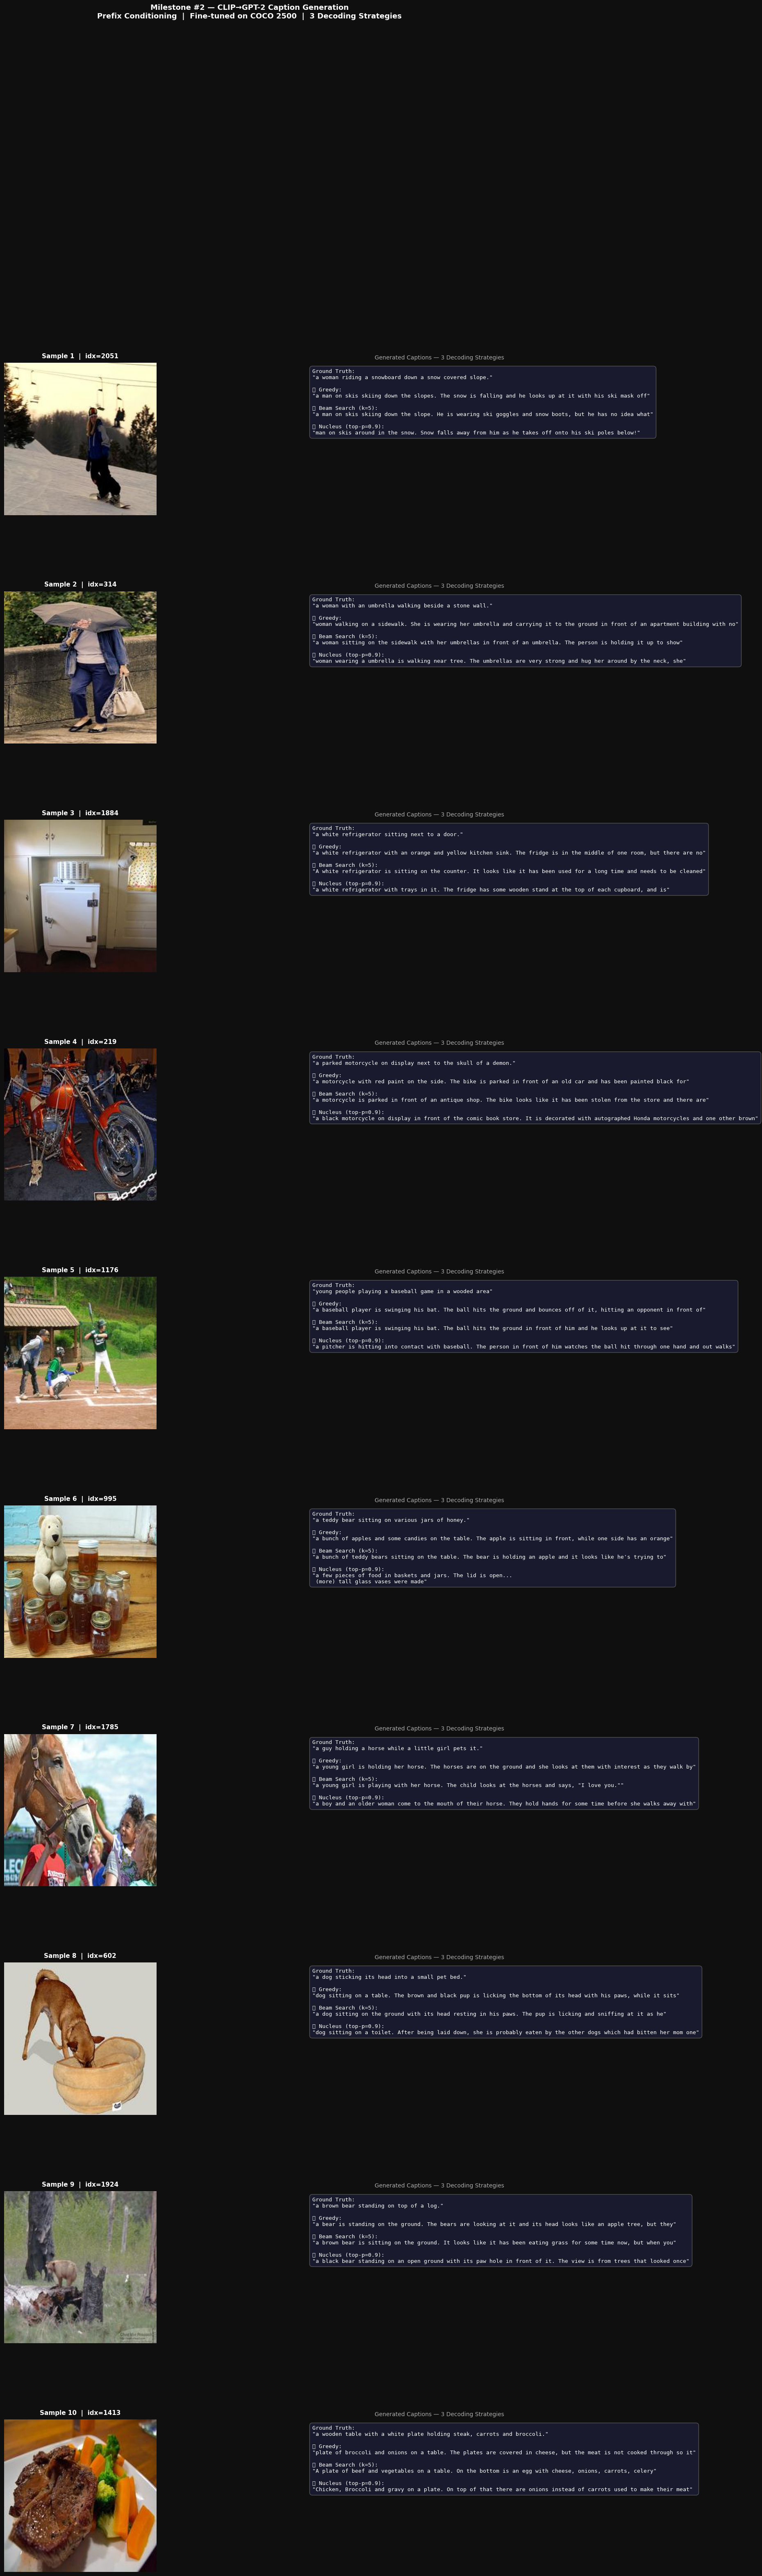


💾 Figure saved → /content/drive/MyDrive/NeuralNetworks_Project2/milestone2/milestone2_captions.png
💾 Results JSON saved → /content/drive/MyDrive/NeuralNetworks_Project2/milestone2/caption_results.json

🎉 Step 7 complete! Proceed to Step 8.


In [16]:
#STEP 7: Generate Captions for 10 Sample Images
# Professor deliverable — show all 3 strategies side by side
# ============================================================

print("=" * 50)
print("   STEP 7: Caption Generation — 10 Sample Images")
print("=" * 50)

NUM_SAMPLES  = 10
OUTPUT_FIG   = M2_DIR / "milestone2_captions.png"
OUTPUT_JSON  = M2_DIR / "caption_results.json"

# ── Pick 10 diverse samples ───────────────────────────────────
np.random.seed(99)
sample_idx = np.random.choice(len(metadata), NUM_SAMPLES, replace=False).tolist()
print(f"🎲 Selected indices: {sample_idx}")

# ── Generate captions for each sample ────────────────────────
print(f"\n🔄 Generating captions (3 strategies × {NUM_SAMPLES} images)...")

results = []
for i, idx in enumerate(sample_idx):
    entry    = metadata[idx]
    img_path = IMG_DIR / entry["file_name"]
    emb      = embeddings[idx]

    img_pil  = Image.open(img_path).convert("RGB")

    greedy  = greedy_decode(emb)
    beam    = beam_search_decode(emb, num_beams=5)
    nucleus = nucleus_decode(emb, top_p=0.9, temperature=1.0)

    results.append({
        "idx"           : idx,
        "file_name"     : entry["file_name"],
        "ground_truth"  : entry["caption"],
        "greedy"        : greedy,
        "beam_search"   : beam,
        "nucleus"       : nucleus,
        "image"         : img_pil,
    })
    print(f"  [{i+1}/{NUM_SAMPLES}] ✅ {entry['file_name']}")
    print(f"    GT      : {entry['caption']}")
    print(f"    Greedy  : {greedy}")
    print(f"    Beam    : {beam}")
    print(f"    Nucleus : {nucleus}\n")

# ── Build submission figure ───────────────────────────────────
print("🖼️  Building figure...")

fig = plt.figure(figsize=(20, 7 * NUM_SAMPLES))
fig.patch.set_facecolor("#0f0f0f")

for row, res in enumerate(results):
    gs = gridspec.GridSpec(NUM_SAMPLES, 2, figure=fig, wspace=0.3, hspace=0.5)

    # Col 0: Image
    ax_img = fig.add_subplot(gs[row, 0])
    ax_img.imshow(res["image"])
    ax_img.axis("off")
    ax_img.set_title(
        f"Sample {row+1}  |  idx={res['idx']}",
        color="white", fontsize=11, fontweight="bold", pad=8
    )

    # Col 1: Captions
    ax_txt = fig.add_subplot(gs[row, 1])
    ax_txt.axis("off")
    ax_txt.set_facecolor("#1a1a2e")

    txt = (
        f"Ground Truth:\n\"{res['ground_truth']}\"\n\n"
        f"① Greedy:\n\"{res['greedy']}\"\n\n"
        f"② Beam Search (k=5):\n\"{res['beam_search']}\"\n\n"
        f"③ Nucleus (top-p=0.9):\n\"{res['nucleus']}\""
    )
    ax_txt.text(
        0.04, 0.96, txt,
        transform=ax_txt.transAxes,
        fontsize=9.5, color="white",
        verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#1a1a2e", edgecolor="#555")
    )
    ax_txt.set_title("Generated Captions — 3 Decoding Strategies", color="#aaaaaa", fontsize=10)

plt.suptitle(
    "Milestone #2 — CLIP→GPT-2 Caption Generation\n"
    "Prefix Conditioning  |  Fine-tuned on COCO 2500  |  3 Decoding Strategies",
    color="white", fontsize=13, fontweight="bold", y=1.005
)
plt.savefig(OUTPUT_FIG, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"\n💾 Figure saved → {OUTPUT_FIG}")

# ── Save JSON results ─────────────────────────────────────────
json_results = [{k: v for k, v in r.items() if k != "image"} for r in results]
with open(OUTPUT_JSON, "w") as f:
    json.dump(json_results, f, indent=2)
print(f"💾 Results JSON saved → {OUTPUT_JSON}")

print("\n" + "=" * 50)
print("🎉 Step 7 complete! Proceed to Step 8.")
print("=" * 50)

In [18]:
import shutil
from PIL import Image

# Best 5 indices from your results list
best_5_indices = [0, 1, 2, 4, 9]
REPORT_IMG_DIR = M2_DIR / "report_images"
REPORT_IMG_DIR.mkdir(exist_ok=True)

for rank, i in enumerate(best_5_indices):
    res = results[i]

    # Save image
    img_save_path = REPORT_IMG_DIR / f"sample_{rank+1}_{res['file_name']}"
    res['image'].save(img_save_path)

    # Print caption info alongside
    print(f"\n── Sample {rank+1} ──────────────────────")
    print(f"  File         : {res['file_name']}")
    print(f"  Ground Truth : {res['ground_truth']}")
    print(f"  Greedy       : {res['greedy']}")
    print(f"  Beam Search  : {res['beam_search']}")
    print(f"  Nucleus      : {res['nucleus']}")

print(f"\n✅ 5 images saved → {REPORT_IMG_DIR}")


── Sample 1 ──────────────────────
  File         : r_000000050158.jpg
  Ground Truth : a woman riding a snowboard down a snow covered slope.
  Greedy       : a man on skis skiing down the slopes. The snow is falling and he looks up at it with his ski mask off
  Beam Search  : a man on skis skiing down the slope. He is wearing ski goggles and snow boots, but he has no idea what
  Nucleus      : man on skis around in the snow. Snow falls away from him as he takes off onto his ski poles below!

── Sample 2 ──────────────────────
  File         : r_000000078803.jpg
  Ground Truth : a woman with an umbrella walking beside a stone wall.
  Greedy       : woman walking on a sidewalk. She is wearing her umbrella and carrying it to the ground in front of an apartment building with no
  Beam Search  : a woman sitting on the sidewalk with her umbrellas in front of an umbrella. The person is holding it up to show
  Nucleus      : woman wearing a umbrella is walking near tree. The umbrellas are ve